<div style="text-align:center; padding:18px; border:2px solid #4f8cff; border-radius:12px;">

# Basic Math for AI-ML Practice

### Assignment #2 — Sec 02

**ชื่อ-นามสกุล:** `ณัฐพล ยิ้มน้อย`

**รหัสนักศึกษา:** `6710110132`

</div>

---
# Library Importing

นำเข้า library ที่ใช้ทั้งหมด พร้อมแสดง **version** ของแต่ละตัว

In [1]:
# เช็คก่อนว่ามี library ครบไหม ถ้าขาดตัวไหนให้ pip install ให้เลย
# ทำแบบนี้เผื่อเอาไฟล์นี้ไปเปิดกับคอมเครื่องอื่น จะได้กด Run All ได้ทันที
import importlib
import subprocess
import sys

packages = ["numpy", "sympy", "pandas", "matplotlib"]

for name in packages:
    try:
        importlib.import_module(name)
    except ImportError:
        print("ไม่มี", name, "-> กำลังติดตั้ง...")
        subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", name])
        # ต้องเรียกอันนี้ด้วย ไม่งั้น Python จะยังจำว่าไม่มี module ตัวนั้นอยู่
        importlib.invalidate_caches()
        print("ติดตั้ง", name, "เสร็จแล้ว")

import numpy as np
import sympy as sp
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline

# ให้ numpy กับ pandas โชว์ทศนิยม 4 ตำแหน่ง จะได้อ่านง่าย
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)

# font ปกติของ matplotlib ไม่มีตัวอักษรไทย เลยต้องเปลี่ยนเป็น Tahoma
# ใส่ DejaVu Sans ต่อท้ายด้วย เพราะ Tahoma ไม่มีสัญลักษณ์คณิตศาสตร์บางตัว
plt.rcParams["font.family"] = ["Tahoma", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# ล็อค seed ไว้ จะได้สุ่มได้ค่าเดิมทุกครั้งที่รัน
np.random.seed(42)

print("เวอร์ชันของ library ที่ใช้")
print("=" * 40)
print("Python     :", sys.version.split()[0])
print("NumPy      :", np.__version__)
print("SymPy      :", sp.__version__)
print("pandas     :", pd.__version__)
print("Matplotlib :", matplotlib.__version__)
print("=" * 40)
print("random seed : 42")

เวอร์ชันของ library ที่ใช้
Python     : 3.11.9
NumPy      : 2.4.4
SymPy      : 1.14.0
pandas     : 3.0.2
Matplotlib : 3.11.1
random seed : 42


---
# Section 1 - Vector

**Vector** คือลำดับของตัวเลขที่มีทั้ง *ขนาด (magnitude)* และ *ทิศทาง (direction)*
ในงาน AI/ML เราใช้ vector แทน ข้อมูล 1 รายการ (sample) หรือ ชุดพารามิเตอร์ (weights)
ในหัวข้อนี้ใช้ vector 3 มิติ ตามโจทย์:

$$
\mathbf{a} = \begin{bmatrix} a_1 \\ a_2 \\ a_3 \end{bmatrix} \in \mathbb{R}^3
\qquad
\mathbf{b} = \begin{bmatrix} b_1 \\ b_2 \\ b_3 \end{bmatrix} \in \mathbb{R}^3
$$

In [2]:
# สุ่ม vector 3 มิติ มา 2 ตัว
a = np.random.randint(-9, 10, 3).astype(float)
b = np.random.randint(-9, 10, 3).astype(float)

print("vector a =", a, " shape =", a.shape)
print("vector b =", b, " shape =", b.shape)

vector a = [-3.  5.  1.]  shape = (3,)
vector b = [-2. -3.  9.]  shape = (3,)


## 1.1a Vector Addition / Subtraction

บวก–ลบแบบ **ทีละตำแหน่ง (element-wise)** ทั้งสอง vector ต้องมีมิติเท่ากัน

$$
\mathbf{a} + \mathbf{b} =
\begin{bmatrix} a_1 + b_1 \\ a_2 + b_2 \\ a_3 + b_3 \end{bmatrix}
\qquad\qquad1
\mathbf{a} - \mathbf{b} =
\begin{bmatrix} a_1 - b_1 \\ a_2 - b_2 \\ a_3 - b_3 \end{bmatrix}
$$

**ความหมายเชิงเรขาคณิต:** การบวกคือการนำลูกศรมาต่อหางกัน (tip-to-tail)

In [3]:
add = a + b
sub = a - b

print("a     =", a)
print("b     =", b)
print("a + b =", add)
print("a - b =", sub)

# ลองบวกลบทีละตัวเอง แล้วเทียบกับที่ numpy ทำให้
manual_add = []
manual_sub = []
for i in range(3):
    manual_add.append(a[i] + b[i])
    manual_sub.append(a[i] - b[i])

print()
print("คำนวณเองได้ผลตรงกับ numpy :", np.allclose(manual_add, add) and np.allclose(manual_sub, sub))

a     = [-3.  5.  1.]
b     = [-2. -3.  9.]
a + b = [-5.  2. 10.]
a - b = [-1.  8. -8.]

คำนวณเองได้ผลตรงกับ numpy : True


## 1.2b Vector Scaling (Scalar Multiplication)

การคูณ vector ด้วย **scalar** $k$ คือการ *ยืด/หด* ความยาว โดย **ทิศทางคงเดิม**
(ถ้า $k < 0$ ทิศทางจะกลับด้าน)

$$
k\mathbf{a} = \begin{bmatrix} k\,a_1 \\ k\,a_2 \\ k\,a_3 \end{bmatrix}
\qquad\text{และ}\qquad
\|k\mathbf{a}\| = |k| \cdot \|\mathbf{a}\|
$$

ใน ML: การอัปเดตน้ำหนักด้วย learning rate $\theta \leftarrow \theta - \alpha \nabla L$ ก็คือการ scale vector gradient นั่นเอง

In [4]:
k1 = 3.0
k2 = -0.5

print("a        =", a)
print("3.0 * a  =", k1 * a)
print("-0.5 * a =", k2 * a)
print()

# เช็คสมบัติ ||k*a|| = |k| * ||a||
lhs = np.linalg.norm(k1 * a)
rhs = abs(k1) * np.linalg.norm(a)

print("||3a||      =", round(lhs, 4))
print("|3| * ||a|| =", round(rhs, 4))
print("สมบัติเป็นจริง :", np.isclose(lhs, rhs))

a        = [-3.  5.  1.]
3.0 * a  = [-9. 15.  3.]
-0.5 * a = [ 1.5 -2.5 -0.5]

||3a||      = 17.7482
|3| * ||a|| = 17.7482
สมบัติเป็นจริง : True


## 1.3c Dot Product (ผลคูณจุด)

$$
\mathbf{a} \cdot \mathbf{b} \;=\; \sum_{i=1}^{n} a_i b_i \;=\; a_1b_1 + a_2b_2 + a_3b_3
$$

ผลลัพธ์เป็น **scalar** (ตัวเลขตัวเดียว) และยังเขียนในรูปมุมระหว่าง vector ได้ว่า

$$
\mathbf{a} \cdot \mathbf{b} = \|\mathbf{a}\|\,\|\mathbf{b}\|\cos\theta
$$

**ความสำคัญใน AI/ML:** neuron 1 ตัวคำนวณ $z = \mathbf{w}\cdot\mathbf{x} + b$ ซึ่งก็คือ dot product นั่นเอง

In [5]:
# dot product ทำได้ 3 แบบ ผลลัพธ์เหมือนกัน
dot_manual = 0
for i in range(3):
    dot_manual += a[i] * b[i]

dot_np = np.dot(a, b)
dot_at = a @ b

print("a =", a)
print("b =", b)
print()
print("คูณทีละตัวแล้วบวกกัน =", dot_manual)
print("np.dot(a, b)         =", dot_np)
print("a @ b                =", dot_at)
print("ตรงกันทั้ง 3 แบบ :", np.allclose([dot_manual, dot_np], dot_at))

a = [-3.  5.  1.]
b = [-2. -3.  9.]

คูณทีละตัวแล้วบวกกัน = 0.0
np.dot(a, b)         = 0.0
a @ b                = 0.0
ตรงกันทั้ง 3 แบบ : True


## 1.4d Magnitude (ความยาว / Norm)

**L2 norm** หรือ Euclidean norm — คือความยาวของลูกศร (ทฤษฎีบทพีทาโกรัสในหลายมิติ)

$$
\|\mathbf{a}\|_2 \;=\; \sqrt{\sum_{i=1}^{n} a_i^2} \;=\; \sqrt{a_1^2 + a_2^2 + a_3^2}
\;=\; \sqrt{\mathbf{a}\cdot\mathbf{a}}
$$

**Unit vector** (เวกเตอร์หนึ่งหน่วย) คือ $\hat{\mathbf{a}} = \dfrac{\mathbf{a}}{\|\mathbf{a}\|}$ ซึ่งมีความยาวเท่ากับ 1

In [6]:
# ขนาดของ vector = รากที่สองของผลรวมกำลังสอง
total = 0
for i in range(3):
    total += a[i] ** 2
mag_manual = np.sqrt(total)

mag_np = np.linalg.norm(a)

print("a =", a)
print("||a|| คำนวณเอง    =", round(mag_manual, 4))
print("np.linalg.norm(a) =", round(mag_np, 4))
print("||b||             =", round(np.linalg.norm(b), 4))
print()

# unit vector คือ vector ทิศเดิมแต่ยาว 1 หน่วย
a_hat = a / np.linalg.norm(a)
print("unit vector ของ a =", a_hat)
print("ความยาวของมัน     =", round(np.linalg.norm(a_hat), 4), "(ต้องได้ 1)")

a = [-3.  5.  1.]
||a|| คำนวณเอง    = 5.9161
np.linalg.norm(a) = 5.9161
||b||             = 9.6954

unit vector ของ a = [-0.5071  0.8452  0.169 ]
ความยาวของมัน     = 1.0 (ต้องได้ 1)


## 1.5e Cosine Similarity

วัด **ความคล้ายเชิงทิศทาง** ของ vector 2 ตัว โดย *ตัดผลของขนาดออก*

$$
\cos\theta = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\|\,\|\mathbf{b}\|}
\qquad \cos\theta \in [-1, 1]
$$

| ค่า | ความหมาย |
|-----|----------|
| $+1$ | ทิศทางเดียวกันสนิท |
| $0$ | ตั้งฉากกัน (ไม่เกี่ยวข้องกัน) |
| $-1$ | ทิศทางตรงกันข้าม |

**การใช้งานใน AI/ML:** เปรียบเทียบความคล้ายของ *embedding* ในงานค้นหาเอกสาร, recommendation และ semantic search

In [7]:
def cosine_similarity(u, v):
    # cos(theta) = (u . v) / (||u|| * ||v||)
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))


cos_ab = cosine_similarity(a, b)
theta = np.degrees(np.arccos(np.clip(cos_ab, -1, 1)))

print("a =", a)
print("b =", b)
print()
print("a . b             =", round(np.dot(a, b), 4))
print("||a|| * ||b||     =", round(np.linalg.norm(a) * np.linalg.norm(b), 4))
print("cosine similarity =", round(cos_ab, 4))
print("มุมระหว่าง vector  =", round(theta, 2), "องศา")
print()

# ลองเคสพิเศษ ดูว่าค่าอยู่ในช่วง -1 ถึง 1 จริงไหม
x_axis = np.array([1.0, 0.0, 0.0])
y_axis = np.array([0.0, 1.0, 0.0])

print("cos(a, 2a) =", round(cosine_similarity(a, 2 * a), 4), "-> ทิศเดียวกัน ขนาดไม่มีผล")
print("cos(a, -a) =", round(cosine_similarity(a, -a), 4), "-> ทิศตรงข้าม")
print("cos(x, y)  =", round(cosine_similarity(x_axis, y_axis), 4), "-> ตั้งฉาก")

a = [-3.  5.  1.]
b = [-2. -3.  9.]

a . b             = 0.0
||a|| * ||b||     = 57.3585
cosine similarity = 0.0
มุมระหว่าง vector  = 90.0 องศา

cos(a, 2a) = 1.0 -> ทิศเดียวกัน ขนาดไม่มีผล
cos(a, -a) = -1.0 -> ทิศตรงข้าม
cos(x, y)  = 0.0 -> ตั้งฉาก


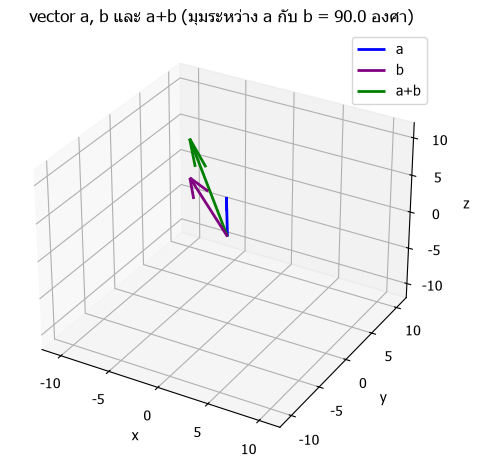

In [8]:
# วาด vector a, b และ a+b ในสามมิติ
c_vec = a + b

fig = plt.figure(figsize=(6.5, 5.5))
ax = fig.add_subplot(111, projection="3d")

ax.quiver(0, 0, 0, a[0], a[1], a[2], color="blue", linewidth=2, label="a")
ax.quiver(0, 0, 0, b[0], b[1], b[2], color="purple", linewidth=2, label="b")
ax.quiver(0, 0, 0, c_vec[0], c_vec[1], c_vec[2], color="green", linewidth=2, label="a+b")

# ให้แกนทั้งสามยาวเท่ากัน ลูกศรจะได้ไม่บิดเบี้ยว
lim = max(abs(np.concatenate([a, b, c_vec]))) * 1.2
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("vector a, b และ a+b (มุมระหว่าง a กับ b = " + str(round(theta, 1)) + " องศา)")
ax.legend()
plt.show()

---
# Section 2 - Matrix

**Matrix** คือ array 2 มิติ ใช้แทน *ชุดข้อมูลทั้งก้อน* (แถว = sample, คอลัมน์ = feature)
หรือแทน *การแปลงเชิงเส้น (linear transformation)*

ในหัวข้อนี้ใช้ matrix ขนาด **3×3** ตามโจทย์:

$$
A = \begin{bmatrix}
a_{11} & a_{12} & a_{13} \\
a_{21} & a_{22} & a_{23} \\
a_{31} & a_{32} & a_{33}
\end{bmatrix} \in \mathbb{R}^{3\times 3}
$$

In [9]:
# สุ่ม matrix ขนาด 3x3 มา 2 ตัว
A = np.random.randint(-5, 6, (3, 3)).astype(float)
B = np.random.randint(-5, 6, (3, 3)).astype(float)

# ถ้าสุ่มได้ det(A) = 0 จะหา inverse ไม่ได้ ต้องสุ่มใหม่
while np.isclose(np.linalg.det(A), 0):
    A = np.random.randint(-5, 6, (3, 3)).astype(float)

print("Matrix A =")
print(A)
print()
print("Matrix B =")
print(B)
print()
print("shape ของ A =", A.shape, " (3 แถว 3 คอลัมน์)")

Matrix A =
[[ 1.  5.  5.]
 [ 2. -1. -2.]
 [ 2.  2. -3.]]

Matrix B =
[[ 0. -1. -4.]
 [ 2.  0. -4.]
 [-1. -5.  4.]]

shape ของ A = (3, 3)  (3 แถว 3 คอลัมน์)


## 2.1a Transpose

สลับแถวกับคอลัมน์ — สมาชิกตำแหน่ง $(i,j)$ ย้ายไปอยู่ที่ $(j,i)$

$$
(A^{T})_{ij} = A_{ji}
\qquad\text{ถ้า } A \in \mathbb{R}^{m\times n} \text{ แล้ว } A^{T} \in \mathbb{R}^{n\times m}
$$

สมบัติสำคัญ: $(A^{T})^{T} = A$ และ $(AB)^{T} = B^{T}A^{T}$ *(ลำดับสลับกัน)*

In [10]:
A_T = A.T

print("A =")
print(A)
print()
print("A transpose =")
print(A_T)
print()
print("เช็คสมบัติของ transpose")
print("  ทำ transpose 2 ครั้ง ได้ A เดิม :", np.allclose(A_T.T, A))
print("  (AB)^T เท่ากับ B^T A^T          :", np.allclose((A @ B).T, B.T @ A.T))

A =
[[ 1.  5.  5.]
 [ 2. -1. -2.]
 [ 2.  2. -3.]]

A transpose =
[[ 1.  2.  2.]
 [ 5. -1.  2.]
 [ 5. -2. -3.]]

เช็คสมบัติของ transpose
  ทำ transpose 2 ครั้ง ได้ A เดิม : True
  (AB)^T เท่ากับ B^T A^T          : True


## 2.2b Matrix Dot Product (การคูณเมทริกซ์)

สมาชิกตำแหน่ง $(i,j)$ ของผลลัพธ์ คือ **dot product ของแถว $i$ ใน $A$ กับคอลัมน์ $j$ ใน $B$**

$$
C_{ij} = \sum_{k=1}^{n} A_{ik} B_{kj}
\qquad\qquad
A_{(m\times n)} \cdot B_{(n\times p)} = C_{(m\times p)}
$$

**กฎเรื่องขนาด:** มิติด้านใน (inner dimensions) ต้องเท่ากัน
และโดยทั่วไป $AB \neq BA$ (การคูณเมทริกซ์ **ไม่มีสมบัติสลับที่**)

In [11]:
C = A @ B     # @ คือการคูณ matrix เหมือน np.matmul

print("A @ B =")
print(C)
print()
print("shape:", A.shape, "@", B.shape, "->", C.shape)
print()

# ลองคำนวณช่อง C[0,0] เอง = แถวแรกของ A dot กับ คอลัมน์แรกของ B
manual_c00 = 0
for k in range(3):
    manual_c00 += A[0, k] * B[k, 0]

print("C[0,0] คำนวณเอง =", manual_c00, " | numpy =", C[0, 0])
print()
print("A @ B เท่ากับ B @ A ไหม :", np.allclose(A @ B, B @ A), " -> ปกติแล้วไม่เท่ากัน")
print()
print("ระวัง A * B คือคูณทีละช่อง ไม่ใช่การคูณ matrix")
print(A * B)

A @ B =
[[  5. -26.  -4.]
 [  0.   8. -12.]
 [  7.  13. -28.]]

shape: (3, 3) @ (3, 3) -> (3, 3)

C[0,0] คำนวณเอง = 5.0  | numpy = 5.0

A @ B เท่ากับ B @ A ไหม : False  -> ปกติแล้วไม่เท่ากัน

ระวัง A * B คือคูณทีละช่อง ไม่ใช่การคูณ matrix
[[  0.  -5. -20.]
 [  4.  -0.   8.]
 [ -2. -10. -12.]]


## 2.3c Determinant

$\det(A)$ เป็น scalar ที่บอกว่าการแปลงด้วย $A$ ทำให้ *ปริมาตร* ขยาย/หดกี่เท่า

สำหรับเมทริกซ์ $3\times3$ ใช้การกระจายตามแถวแรก (cofactor expansion):

$$
\det(A) = a_{11}\begin{vmatrix} a_{22} & a_{23} \\ a_{32} & a_{33}\end{vmatrix}
        - a_{12}\begin{vmatrix} a_{21} & a_{23} \\ a_{31} & a_{33}\end{vmatrix}
        + a_{13}\begin{vmatrix} a_{21} & a_{22} \\ a_{31} & a_{32}\end{vmatrix}
$$

**ความหมาย:** ถ้า $\det(A) = 0$ เรียกว่า **singular** — การแปลงบีบปริภูมิให้แบนลง ทำให้ **หา inverse ไม่ได้**

In [12]:
det_np = np.linalg.det(A)

# หา det เอง โดยกระจายตามแถวแรก
m11 = A[1, 1] * A[2, 2] - A[1, 2] * A[2, 1]
m12 = A[1, 0] * A[2, 2] - A[1, 2] * A[2, 0]
m13 = A[1, 0] * A[2, 1] - A[1, 1] * A[2, 0]
det_manual = A[0, 0] * m11 - A[0, 1] * m12 + A[0, 2] * m13

print("A =")
print(A)
print()
print("det(A) คำนวณเอง  =", round(det_manual, 4))
print("np.linalg.det(A) =", round(det_np, 4))
print("ตรงกัน :", np.isclose(det_manual, det_np))
print()
print("det เป็น 0 ไหม :", np.isclose(det_np, 0), " -> ไม่เป็น 0 เลยหา inverse ได้")

A =
[[ 1.  5.  5.]
 [ 2. -1. -2.]
 [ 2.  2. -3.]]

det(A) คำนวณเอง  = 47.0
np.linalg.det(A) = 47.0
ตรงกัน : True

det เป็น 0 ไหม : False  -> ไม่เป็น 0 เลยหา inverse ได้


## 2.4d Inverse

$A^{-1}$ คือเมทริกซ์ที่ "ย้อนกลับ" การแปลงของ $A$

$$
A A^{-1} = A^{-1} A = I
\qquad\qquad
A^{-1} = \frac{1}{\det(A)}\,\mathrm{adj}(A)
$$

**เงื่อนไข:** ต้องเป็นเมทริกซ์จัตุรัส และ $\det(A) \neq 0$

> **ข้อควรระวังในทางปฏิบัติ:** เวลาแก้ระบบสมการ $A\mathbf{x} = \mathbf{b}$
> ควรใช้ `np.linalg.solve(A, b)` แทนการคูณด้วย $A^{-1}$ เพราะ **เสถียรเชิงตัวเลข (numerically stable) มากกว่า**

In [13]:
A_inv = np.linalg.inv(A)

print("A inverse =")
print(A_inv)
print()
print("A @ A_inv =")
print(np.round(A @ A_inv, 10))    # ปัดเศษก่อน ไม่งั้นจะเห็น error ของทศนิยมติดมา
print()
print("ได้ identity matrix ไหม :", np.allclose(A @ A_inv, np.eye(3)))
print()

# เอา inverse ไปใช้แก้ระบบสมการ A x = b
b_vec = np.random.randint(-5, 6, 3).astype(float)
x_solve = np.linalg.solve(A, b_vec)
x_inv = A_inv @ b_vec

print("แก้ระบบสมการ A x = b โดย b =", b_vec)
print("  np.linalg.solve(A, b) =", x_solve)
print("  A_inv @ b             =", x_inv)
print("  ลองแทนกลับ A @ x     =", A @ x_solve, " (ควรได้ b)")

A inverse =
[[ 0.1489  0.5319 -0.1064]
 [ 0.0426 -0.2766  0.2553]
 [ 0.1277  0.1702 -0.234 ]]

A @ A_inv =
[[ 1. -0.  0.]
 [ 0.  1.  0.]
 [ 0. -0.  1.]]

ได้ identity matrix ไหม : True

แก้ระบบสมการ A x = b โดย b = [ 0.  3. -5.]
  np.linalg.solve(A, b) = [ 2.1277 -2.1064  1.6809]
  A_inv @ b             = [ 2.1277 -2.1064  1.6809]
  ลองแทนกลับ A @ x     = [-0.  3. -5.]  (ควรได้ b)


## 2.5e Rank

**Rank** = จำนวน *แถว (หรือคอลัมน์) ที่เป็นอิสระเชิงเส้นต่อกัน* = จำนวนมิติที่ข้อมูลกางออกได้จริง

$$
\mathrm{rank}(A) \le \min(m, n)
$$

- **Full rank** ($\mathrm{rank} = 3$ สำหรับ $3\times3$) → ไม่มีแถวไหนซ้ำซ้อน, $\det \ne 0$, มี inverse
- **Rank ต่ำกว่าขนาด** → มี feature ที่เป็นผลรวมเชิงเส้นของ feature อื่น (ข้อมูลซ้ำซ้อน / multicollinearity)

In [14]:
rank_A = np.linalg.matrix_rank(A)

print("rank(A) =", rank_A, " จาก matrix ขนาด", A.shape)
if rank_A == 3:
    print("-> full rank ทุกแถวเป็นอิสระต่อกัน")
print()

# ลองสร้าง matrix ที่ rank ต่ำ โดยให้แถว 3 เป็น 2 เท่าของแถว 1
S = A.copy()
S[2, :] = 2 * S[0, :]

print("Matrix S (แถว 3 = 2 เท่าของแถว 1) =")
print(S)
print()
print("rank(S) =", np.linalg.matrix_rank(S), " -> ลดลง เพราะแถวไม่เป็นอิสระ")
print("det(S)  =", round(np.linalg.det(S), 4), " -> เป็น 0 เลยหา inverse ไม่ได้")

rank(A) = 3  จาก matrix ขนาด (3, 3)
-> full rank ทุกแถวเป็นอิสระต่อกัน

Matrix S (แถว 3 = 2 เท่าของแถว 1) =
[[ 1.  5.  5.]
 [ 2. -1. -2.]
 [ 2. 10. 10.]]

rank(S) = 2  -> ลดลง เพราะแถวไม่เป็นอิสระ
det(S)  = 0.0  -> เป็น 0 เลยหา inverse ไม่ได้


---
# Section 3 - Eigenvalues and Eigenvectors

เมื่อคูณเมทริกซ์ $A$ เข้ากับ vector ส่วนใหญ่ ทิศทางจะเปลี่ยนไป
แต่มี vector บางตัวที่ **ทิศทางไม่เปลี่ยน** มีแค่ถูก *ยืดหรือหด* เท่านั้น — เรียกว่า **eigenvector**

$$
A\mathbf{v} = \lambda \mathbf{v}
\qquad (\mathbf{v} \neq \mathbf{0})
$$

- $\mathbf{v}$ = **eigenvector** → ทิศทางที่การแปลงรักษาไว้
- $\lambda$ = **eigenvalue** → อัตราการยืด/หดตามทิศนั้น

หาได้จาก **characteristic equation**:

$$
\det(A - \lambda I) = 0
$$

**การใช้งานใน AI/ML:** eigenvector ของ *covariance matrix* คือแกนหลัก (principal components) ใน **PCA**
โดย eigenvalue ที่มากแปลว่าข้อมูลกระจายตัว (variance) มากในทิศนั้น

In [15]:
# ใช้ symmetric matrix เพราะ eigenvalue จะเป็นจำนวนจริงทั้งหมด
# (covariance matrix ที่ใช้ใน PCA ก็เป็นแบบนี้)
M = np.random.randint(1, 6, (3, 3)).astype(float)
M = (M + M.T) / 2

print("Matrix M =")
print(M)
print("เป็น symmetric ไหม :", np.allclose(M, M.T))
print()

eigenvalues, eigenvectors = np.linalg.eig(M)

print("Eigenvalues:")
for i in range(3):
    print("  lambda", i + 1, "=", round(eigenvalues[i], 4))
print()
print("Eigenvectors (อ่านทีละคอลัมน์ แต่ละอันยาว 1):")
print(eigenvectors)

Matrix M =
[[3.  3.5 3. ]
 [3.5 4.  3.5]
 [3.  3.5 1. ]]
เป็น symmetric ไหม : True

Eigenvalues:
  lambda 1 = 9.5274
  lambda 2 = -0.0352
  lambda 3 = -1.4923

Eigenvectors (อ่านทีละคอลัมน์ แต่ละอันยาว 1):
[[-0.5754 -0.7612 -0.2993]
 [-0.6654  0.6484 -0.3698]
 [-0.4755  0.0136  0.8796]]


In [16]:
# เช็คว่า M v = lambda v เป็นจริงไหม
print("ตรวจสอบสมการ M v = lambda v ทีละคู่")
print("=" * 50)

for i in range(3):
    lam = eigenvalues[i]
    v = eigenvectors[:, i]
    lhs = M @ v
    rhs = lam * v

    print()
    print("คู่ที่", i + 1, ": lambda =", round(lam, 4))
    print("  v          =", v)
    print("  M @ v      =", lhs)
    print("  lambda * v =", rhs)
    print("  เท่ากัน :", np.allclose(lhs, rhs))

print()
print("=" * 50)
print("ผลรวม eigenvalue =", round(eigenvalues.sum(), 4), " | trace(M) =", round(np.trace(M), 4))
print("ผลคูณ eigenvalue =", round(np.prod(eigenvalues), 4), " | det(M)   =", round(np.linalg.det(M), 4))

ตรวจสอบสมการ M v = lambda v ทีละคู่

คู่ที่ 1 : lambda = 9.5274
  v          = [-0.5754 -0.6654 -0.4755]
  M @ v      = [-5.4818 -6.3399 -4.5307]
  lambda * v = [-5.4818 -6.3399 -4.5307]
  เท่ากัน : True

คู่ที่ 2 : lambda = -0.0352
  v          = [-0.7612  0.6484  0.0136]
  M @ v      = [ 0.0268 -0.0228 -0.0005]
  lambda * v = [ 0.0268 -0.0228 -0.0005]
  เท่ากัน : True

คู่ที่ 3 : lambda = -1.4923
  v          = [-0.2993 -0.3698  0.8796]
  M @ v      = [ 0.4466  0.5519 -1.3126]
  lambda * v = [ 0.4466  0.5519 -1.3126]
  เท่ากัน : True

ผลรวม eigenvalue = 8.0  | trace(M) = 8.0
ผลคูณ eigenvalue = 0.5  | det(M)   = 0.5


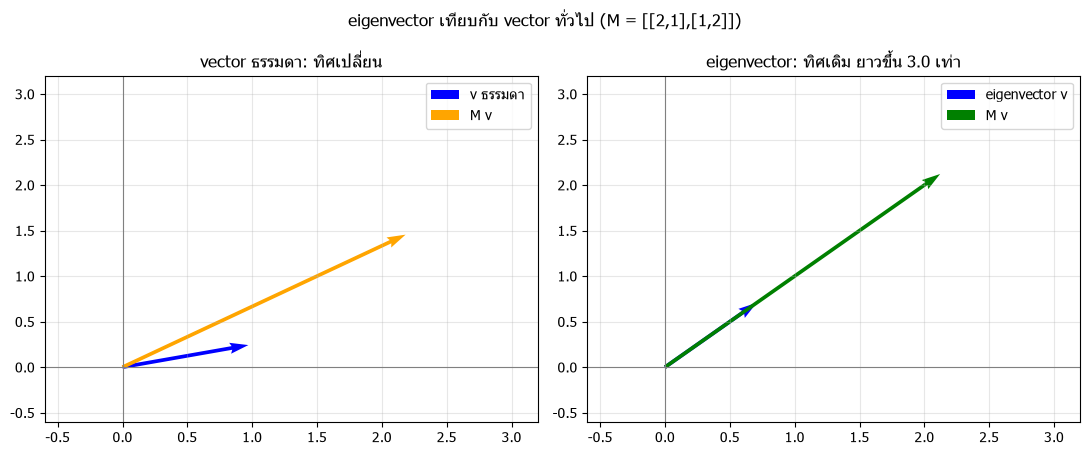

In [17]:
# เทียบให้เห็นว่า eigenvector ไม่เปลี่ยนทิศ แต่ vector ทั่วไปเปลี่ยน
# ใช้ matrix 2x2 จะได้วาดบนระนาบได้
M2 = np.array([[2.0, 1.0], [1.0, 2.0]])
w2, V2 = np.linalg.eig(M2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

# รูปซ้าย vector ธรรมดา พอคูณ M แล้วทิศเปลี่ยน
v_gen = np.array([1.0, 0.25])
v_gen = v_gen / np.linalg.norm(v_gen)
Mv = M2 @ v_gen
axes[0].quiver(0, 0, v_gen[0], v_gen[1], angles="xy", scale_units="xy", scale=1,
               color="blue", label="v ธรรมดา")
axes[0].quiver(0, 0, Mv[0], Mv[1], angles="xy", scale_units="xy", scale=1,
               color="orange", label="M v")
axes[0].set_title("vector ธรรมดา: ทิศเปลี่ยน")

# รูปขวา eigenvector ทิศเดิม แค่ยาวขึ้นตาม lambda
v_eig = V2[:, 0]
Mv_eig = M2 @ v_eig
axes[1].quiver(0, 0, v_eig[0], v_eig[1], angles="xy", scale_units="xy", scale=1,
               color="blue", label="eigenvector v")
axes[1].quiver(0, 0, Mv_eig[0], Mv_eig[1], angles="xy", scale_units="xy", scale=1,
               color="green", label="M v")
axes[1].set_title("eigenvector: ทิศเดิม ยาวขึ้น " + str(round(w2[0], 2)) + " เท่า")

for i in range(2):
    axes[i].set_xlim(-0.6, 3.2)
    axes[i].set_ylim(-0.6, 3.2)
    axes[i].axhline(0, color="gray", lw=0.8)
    axes[i].axvline(0, color="gray", lw=0.8)
    axes[i].grid(alpha=0.3)
    axes[i].legend()

plt.suptitle("eigenvector เทียบกับ vector ทั่วไป (M = [[2,1],[1,2]])")
plt.tight_layout()
plt.show()

---
# Section 4 - Calculus

Calculus ตอบคำถามเดียวที่สำคัญที่สุดในการเทรนโมเดล:
> **"ถ้าขยับพารามิเตอร์ไปนิดหนึ่ง ค่า loss จะเปลี่ยนไปเท่าไหร่ และควรขยับไปทางไหน?"**

ในหัวข้อนี้ใช้ **SymPy** หาอนุพันธ์แบบสัญลักษณ์ (ได้สูตรออกมาจริง ๆ) แล้วนำไปพล็อตเทียบกับฟังก์ชันต้นฉบับ

## 4.1a Derivative (อนุพันธ์)

อนุพันธ์คือ **อัตราการเปลี่ยนแปลงชั่วขณะ** = ความชันของเส้นสัมผัส ณ จุดนั้น

$$
f'(x) = \frac{df}{dx} = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}
$$

**กฎที่ใช้บ่อย**

$$
\frac{d}{dx}(c) = 0 \qquad
\frac{d}{dx}(x^{n}) = n x^{n-1} \qquad
\frac{d}{dx}(e^{x}) = e^{x} \qquad
\frac{d}{dx}\big(af + bg\big) = af' + bg'
$$

ตัวอย่างที่ใช้: $f(x) = 3x^{3} - 5x^{2} + 2x + 7$

In [18]:
x = sp.symbols("x")
f = 3*x**3 - 5*x**2 + 2*x + 7

f_prime = sp.diff(f, x)        # อนุพันธ์อันดับ 1
f_second = sp.diff(f, x, 2)    # อนุพันธ์อันดับ 2

print("f(x)   =", f)
print("f'(x)  =", f_prime)
print("f''(x) =", f_second)
print()

# จุดวิกฤตคือจุดที่ f'(x) = 0
critical = sp.solve(f_prime, x)

print("จุดวิกฤต (f'(x) = 0):")
for c in critical:
    if f_second.subs(x, c) > 0:
        kind = "จุดต่ำสุดเฉพาะที่ (local min)"
    else:
        kind = "จุดสูงสุดเฉพาะที่ (local max)"
    print("  x =", round(float(c), 4), " f(x) =", round(float(f.subs(x, c)), 4), " ->", kind)

f(x)   = 3*x**3 - 5*x**2 + 2*x + 7
f'(x)  = 9*x**2 - 10*x + 2
f''(x) = 2*(9*x - 5)

จุดวิกฤต (f'(x) = 0):
  x = 0.2616  f(x) = 7.2347  -> จุดสูงสุดเฉพาะที่ (local max)
  x = 0.8495  f(x) = 6.9299  -> จุดต่ำสุดเฉพาะที่ (local min)


In [19]:
# ลองเทียบ derivative จากสูตร กับ การหาจากนิยาม limit
f_num = sp.lambdify(x, f, "numpy")          # แปลงสมการ sympy เป็นฟังก์ชันที่คำนวณตัวเลขได้
fp_num = sp.lambdify(x, f_prime, "numpy")

x0 = 2.0
h = 1e-6
numeric = (f_num(x0 + h) - f_num(x0)) / h   # ตามนิยาม limit
symbolic = fp_num(x0)                       # จากสูตรที่ sympy หาให้

print("ที่จุด x =", x0)
print("  f(2)           =", round(f_num(x0), 4))
print("  f'(2) จากสูตร   =", round(symbolic, 6))
print("  f'(2) จากนิยาม  =", round(numeric, 6), " (h =", h, ")")
print("  ต่างกันแค่      =", abs(symbolic - numeric), " -> ถือว่าตรงกัน")

ที่จุด x = 2.0
  f(2)           = 15.0
  f'(2) จากสูตร   = 18.0
  f'(2) จากนิยาม  = 18.000013  (h = 1e-06 )
  ต่างกันแค่      = 1.300544806781545e-05  -> ถือว่าตรงกัน


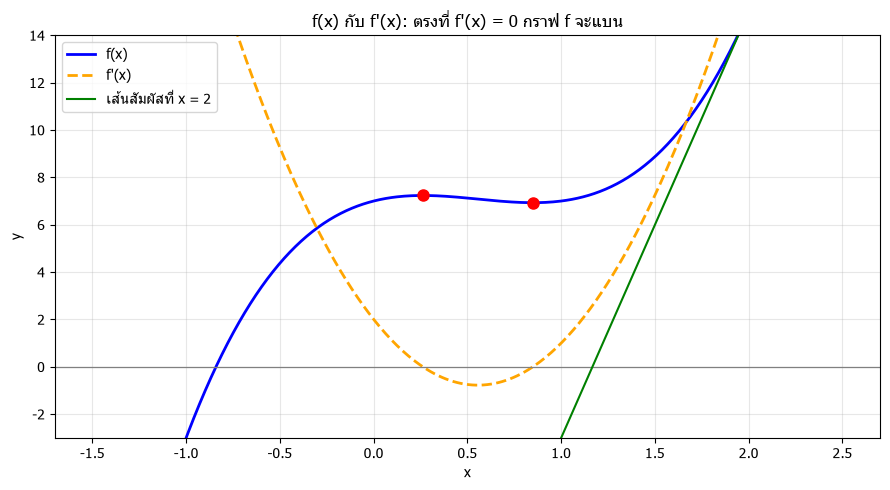

In [20]:
# พล็อต f(x) กับ f'(x) เทียบกัน
xs = np.linspace(-1.5, 2.5, 400)
ys = f_num(xs)
dys = fp_num(xs)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(xs, ys, color="blue", lw=2, label="f(x)")
ax.plot(xs, dys, color="orange", lw=2, ls="--", label="f'(x)")
ax.axhline(0, color="gray", lw=0.9)

# ทำจุดแดงตรงจุดวิกฤต จะเห็นว่าเป็นตำแหน่งที่กราฟ f แบนพอดี
for c in critical:
    cv = float(c)
    ax.plot(cv, f_num(cv), "o", color="red", ms=8)

# ลากเส้นสัมผัสที่ x = 2 เพื่อดูความหมายของความชัน
xt = 2.0
tangent = f_num(xt) + fp_num(xt) * (xs - xt)
ax.plot(xs, tangent, color="green", lw=1.5, label="เส้นสัมผัสที่ x = 2")
ax.plot(xt, f_num(xt), "o", color="green", ms=8)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("f(x) กับ f'(x): ตรงที่ f'(x) = 0 กราฟ f จะแบน")
ax.set_ylim(-3, 14)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4.2b Partial Derivative (อนุพันธ์ย่อย)

เมื่อฟังก์ชันมี **หลายตัวแปร** เราหาอนุพันธ์ *ทีละตัวแปร* โดย **ตรึงตัวแปรอื่นให้เป็นค่าคงที่**

$$
\frac{\partial f}{\partial x}, \qquad \frac{\partial f}{\partial y}
$$

### ตั้งต้นสำหรับ Gradient Descent

เราจะใช้แบบจำลอง **linear regression** และ loss แบบ **MSE** ซึ่งเป็นตัวอย่างมาตรฐาน

$$
\hat{y}_i = w x_i + b
\qquad\qquad
L(w,b) = \mathrm{MSE} = \frac{1}{n}\sum_{i=1}^{n}\big(y_i - (w x_i + b)\big)^{2}
$$

หา partial derivative ของ loss เทียบกับพารามิเตอร์แต่ละตัว (นี่คือสิ่งที่ optimizer ต้องใช้):

$$
\frac{\partial L}{\partial w} = -\frac{2}{n}\sum_{i=1}^{n} x_i\big(y_i - (w x_i + b)\big)
\qquad
\frac{\partial L}{\partial b} = -\frac{2}{n}\sum_{i=1}^{n}\big(y_i - (w x_i + b)\big)
$$

In [21]:
# partial derivative ของฟังก์ชัน 2 ตัวแปร
xs_, ys_ = sp.symbols("x y")
g = xs_**2 + 3*ys_**2 + 2*xs_*ys_

dg_dx = sp.diff(g, xs_)
dg_dy = sp.diff(g, ys_)

print("g(x,y) =", g)
print("dg/dx  =", dg_dx)
print("dg/dy  =", dg_dy)
print()
print("ที่จุด (x,y) = (2,1)")
print("  dg/dx =", dg_dx.subs({xs_: 2, ys_: 1}))
print("  dg/dy =", dg_dy.subs({xs_: 2, ys_: 1}))

g(x,y) = x**2 + 2*x*y + 3*y**2
dg/dx  = 2*x + 2*y
dg/dy  = 2*x + 6*y

ที่จุด (x,y) = (2,1)
  dg/dx = 6
  dg/dy = 10


In [22]:
# partial derivative ของ MSE loss เอาไปใช้ต่อในหัวข้อ gradient descent
w, b, xi, yi = sp.symbols("w b x_i y_i")

y_pred = w*xi + b            # โมเดลเส้นตรง
err_sq = (yi - y_pred)**2    # error ยกกำลังสอง ของข้อมูล 1 ตัว

dL_dw = sp.simplify(sp.diff(err_sq, w))
dL_db = sp.simplify(sp.diff(err_sq, b))

print("error ของ 1 ตัวอย่าง =", err_sq)
print()
print("อนุพันธ์ย่อยเทียบกับพารามิเตอร์")
print("  d/dw =", dL_dw)
print("  d/db =", dL_db)
print()
print("พอเฉลี่ยทั้ง n ตัว จะได้ gradient ของ MSE")
print("  dL/dw = -(2/n) * sum( x_i * (y_i - (w*x_i + b)) )")
print("  dL/db = -(2/n) * sum( y_i - (w*x_i + b) )")

error ของ 1 ตัวอย่าง =

 (-b - w*x_i + y_i)**2

อนุพันธ์ย่อยเทียบกับพารามิเตอร์
  d/dw = 2*x_i*(b + w*x_i - y_i)
  d/db = 2*b + 2*w*x_i - 2*y_i

พอเฉลี่ยทั้ง n ตัว จะได้ gradient ของ MSE
  dL/dw = -(2/n) * sum( x_i * (y_i - (w*x_i + b)) )
  dL/db = -(2/n) * sum( y_i - (w*x_i + b) )


## 4.3c Gradient
**Gradient** คือ vector ที่รวม partial derivative ของทุกตัวแปรเข้าด้วยกัน

$$
\nabla f = \begin{bmatrix}
\dfrac{\partial f}{\partial x} \\[6pt]
\dfrac{\partial f}{\partial y}
\end{bmatrix}
$$

**ความหมาย:**
- $\nabla f$ ชี้ไปทาง **ที่ค่าฟังก์ชันเพิ่มขึ้นเร็วที่สุด** (steepest ascent)
- $-\nabla f$ ชี้ไปทาง **ที่ค่าลดลงเร็วที่สุด** ← ทิศที่ gradient descent เดิน
- ขนาด $\|\nabla f\|$ บอกว่าความชัน ณ จุดนั้นชันแค่ไหน

In [23]:
print("gradient ของ g(x,y) = x^2 + 3y^2 + 2xy")
print("  dg/dx =", dg_dx)
print("  dg/dy =", dg_dy)
print()

points = [(2, 1), (0, 0), (-1, 2)]

print("ค่า gradient ที่จุดต่าง ๆ")
for px, py in points:
    gx_val = float(dg_dx.subs({xs_: px, ys_: py}))
    gy_val = float(dg_dy.subs({xs_: px, ys_: py}))
    size = np.sqrt(gx_val**2 + gy_val**2)
    print("  ที่", (px, py), ": gradient =", [gx_val, gy_val], " ขนาด =", round(size, 4))

print()
print("ที่ (0,0) gradient เป็นศูนย์ แปลว่าเป็นจุดวิกฤต (จุดต่ำสุดของฟังก์ชันนี้)")

gradient ของ g(x,y) = x^2 + 3y^2 + 2xy
  dg/dx = 2*x + 2*y
  dg/dy = 2*x + 6*y

ค่า gradient ที่จุดต่าง ๆ
  ที่ (2, 1) : gradient = [6.0, 10.0]  ขนาด = 11.6619
  ที่ (0, 0) : gradient = [0.0, 0.0]  ขนาด = 0.0
  ที่ (-1, 2) : gradient = [2.0, 10.0]  ขนาด = 10.198

ที่ (0,0) gradient เป็นศูนย์ แปลว่าเป็นจุดวิกฤต (จุดต่ำสุดของฟังก์ชันนี้)


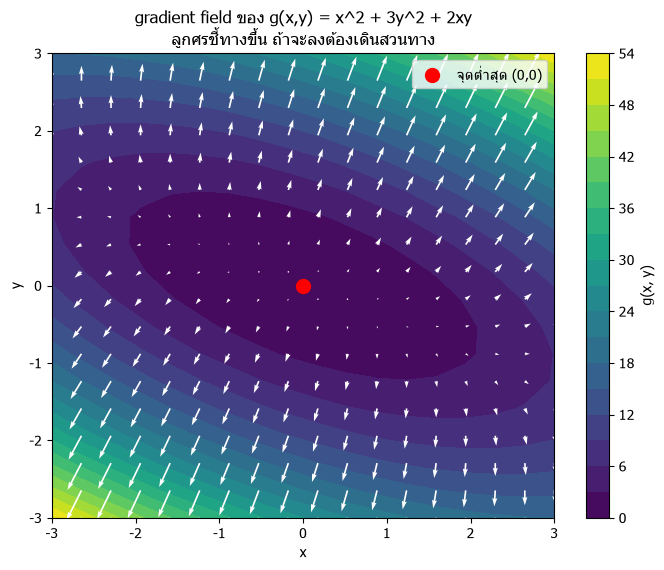

In [24]:
# วาด gradient field ลูกศรจะชี้ไปทางที่ค่าเพิ่มขึ้นเร็วที่สุด
gx, gy = np.meshgrid(np.linspace(-3, 3, 18), np.linspace(-3, 3, 18))
G = gx**2 + 3*gy**2 + 2*gx*gy
U = 2*gx + 2*gy      # dg/dx
V = 6*gy + 2*gx      # dg/dy

fig, ax = plt.subplots(figsize=(7, 5.8))
cs = ax.contourf(gx, gy, G, levels=20, cmap="viridis")
ax.quiver(gx, gy, U, V, color="white")
ax.plot(0, 0, "o", color="red", ms=10, label="จุดต่ำสุด (0,0)")

plt.colorbar(cs, ax=ax, label="g(x, y)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("gradient field ของ g(x,y) = x^2 + 3y^2 + 2xy\nลูกศรชี้ทางขึ้น ถ้าจะลงต้องเดินสวนทาง")
ax.legend()
plt.tight_layout()
plt.show()

## 4.4d Gradient Descent

### แนวคิด

Gradient Descent คืออัลกอริทึมหา *ค่าต่ำสุด* ของ loss function โดยทำซ้ำ 3 ขั้นตอน:

1. คำนวณ **loss** ปัจจุบัน
2. คำนวณ **gradient** (ความชัน) ของ loss เทียบกับพารามิเตอร์
3. ขยับพารามิเตอร์ **สวนทาง gradient** เป็นระยะตาม learning rate

$$
\theta \;\leftarrow\; \theta - \alpha \nabla L(\theta)
$$

โดยที่ $\alpha$ = **learning rate** (ขนาดก้าว)

| $\alpha$ | ผลที่เกิด |
|----------|-----------|
| เล็กเกินไป | ลู่เข้าช้ามาก เสียเวลาเทรน |
| พอเหมาะ | ลู่เข้าสู่จุดต่ำสุดอย่างราบรื่น |
| ใหญ่เกินไป | ก้าวข้ามจุดต่ำสุด แกว่งหรือ **ลู่ออก (diverge)** |

### สมการที่ใช้ในตัวอย่างนี้

**โมเดล:** $\hat{y} = wx + b$ **· Loss:** $L = \mathrm{MSE} = \dfrac{1}{n}\sum(y_i-\hat{y}_i)^2$

**กฎการอัปเดต:**

$$
w \leftarrow w - \alpha\frac{\partial L}{\partial w}
\qquad\qquad
b \leftarrow b - \alpha\frac{\partial L}{\partial b}
$$

**การทดลอง:** กำหนด learning rate แล้วคำนวณ **5 รอบ** ตามโจทย์ เพื่อดูการเปลี่ยนแปลงของค่าต่าง ๆ

In [25]:
# สร้างข้อมูลสุ่มไว้ทำ linear regression
n_samples = 30
true_w = 3.0
true_b = 2.0

X_data = np.random.uniform(-2, 2, n_samples)
noise = np.random.normal(0, 0.7, n_samples)     # ใส่ noise ให้เหมือนข้อมูลจริง
y_data = true_w * X_data + true_b + noise

print("จำนวนข้อมูล =", n_samples)
print("ค่าจริงที่อยากให้โมเดลเรียนได้ : w =", true_w, ", b =", true_b)
print()
print("ข้อมูล 5 แถวแรก")
display(pd.DataFrame({"x": X_data[:5], "y": y_data[:5]}))

จำนวนข้อมูล = 30
ค่าจริงที่อยากให้โมเดลเรียนได้ : w = 3.0 , b = 2.0

ข้อมูล 5 แถวแรก


,x,y
0,-1.8142,-4.1490
1,0.4302,2.1822
2,-1.3179,-1.4121
3,-1.7398,-3.5961
4,1.7955,6.4440


In [26]:
# ฟังก์ชัน loss กับ gradient ตามสมการที่หาไว้ในหัวข้อ 5.2
def predict(X, w, b):
    return w * X + b


def mse_loss(X, y, w, b):
    return np.mean((y - predict(X, w, b)) ** 2)


def gradients(X, y, w, b):
    n = len(X)
    error = y - predict(X, w, b)
    dw = -(2 / n) * np.sum(X * error)
    db = -(2 / n) * np.sum(error)
    return dw, db


# ค่าเริ่มต้น
w_cur = 0.0
b_cur = 0.0
lr = 0.1        # learning rate
n_iter = 5      # จำนวนรอบตามโจทย์

print("เริ่มจาก w =", w_cur, ", b =", b_cur)
print("learning rate =", lr)
print("จำนวนรอบ      =", n_iter)
print("loss เริ่มต้น  =", round(mse_loss(X_data, y_data, w_cur, b_cur), 6))

เริ่มจาก w = 0.0 , b = 0.0
learning rate = 0.1
จำนวนรอบ      = 5
loss เริ่มต้น  = 18.841231


In [27]:
# รัน gradient descent 5 รอบ เก็บค่าทุกรอบไว้ทำตาราง
history = []
w_cur = 0.0
b_cur = 0.0

for step in range(n_iter):
    loss = mse_loss(X_data, y_data, w_cur, b_cur)
    dw, db = gradients(X_data, y_data, w_cur, b_cur)

    # อัปเดตพารามิเตอร์: ค่าใหม่ = ค่าเดิม - lr * gradient
    w_new = w_cur - lr * dw
    b_new = b_cur - lr * db

    history.append({
        "iteration": step,
        "w": w_cur,
        "b": b_cur,
        "MSE_loss": loss,
        "dL/dw": dw,
        "dL/db": db,
        "w_new": w_new,
        "b_new": b_new,
    })

    print("รอบที่", step + 1, ": loss =", round(loss, 5),
          "| dL/dw =", round(dw, 5), "| dL/db =", round(db, 5),
          "| w ->", round(w_new, 5), ", b ->", round(b_new, 5))

    w_cur = w_new
    b_cur = b_new

final_loss = mse_loss(X_data, y_data, w_cur, b_cur)

print()
print("=" * 60)
print("ครบ", n_iter, "รอบแล้ว : w =", round(w_cur, 5), ", b =", round(b_cur, 5),
      ", loss =", round(final_loss, 5))
print("ค่าจริงคือ w =", true_w, ", b =", true_b)
print("loss ลดจาก", round(history[0]["MSE_loss"], 5), "เหลือ", round(final_loss, 5))

รอบที่ 1 : loss = 18.84123 | dL/dw = -9.99809 | dL/db = -3.78697 | w -> 0.99981 , b -> 0.3787
รอบที่ 2 : loss = 9.28346 | dL/dw = -6.50015 | dL/db = -3.13269 | w -> 1.64982 , b -> 0.69197
รอบที่ 3 : loss = 4.90139 | dL/dw = -4.23292 | dL/db = -2.57319 | w -> 2.07312 , b -> 0.94928
รอบที่ 4 : loss = 2.81941 | dL/dw = -2.76199 | dL/db = -2.10221 | w -> 2.34932 , b -> 1.1595
รอบที่ 5 : loss = 1.78776 | dL/dw = -1.80657 | dL/db = -1.71025 | w -> 2.52997 , b -> 1.33053

ครบ 5 รอบแล้ว : w = 2.52997 , b = 1.33053 , loss = 1.25269
ค่าจริงคือ w = 3.0 , b = 2.0
loss ลดจาก 18.84123 เหลือ 1.25269


In [28]:
# เอา history มาทำเป็นตาราง จะได้ดูง่าย
hist_df = pd.DataFrame(history)
display(hist_df)

,iteration,w,b,MSE_loss,dL/dw,dL/db,w_new,b_new
0,0,0.0000,0.0000,18.8412,-9.9981,-3.7870,0.9998,0.3787
1,1,0.9998,0.3787,9.2835,-6.5002,-3.1327,1.6498,0.6920
2,2,1.6498,0.6920,4.9014,-4.2329,-2.5732,2.0731,0.9493
3,3,2.0731,0.9493,2.8194,-2.7620,-2.1022,2.3493,1.1595
4,4,2.3493,1.1595,1.7878,-1.8066,-1.7103,2.5300,1.3305


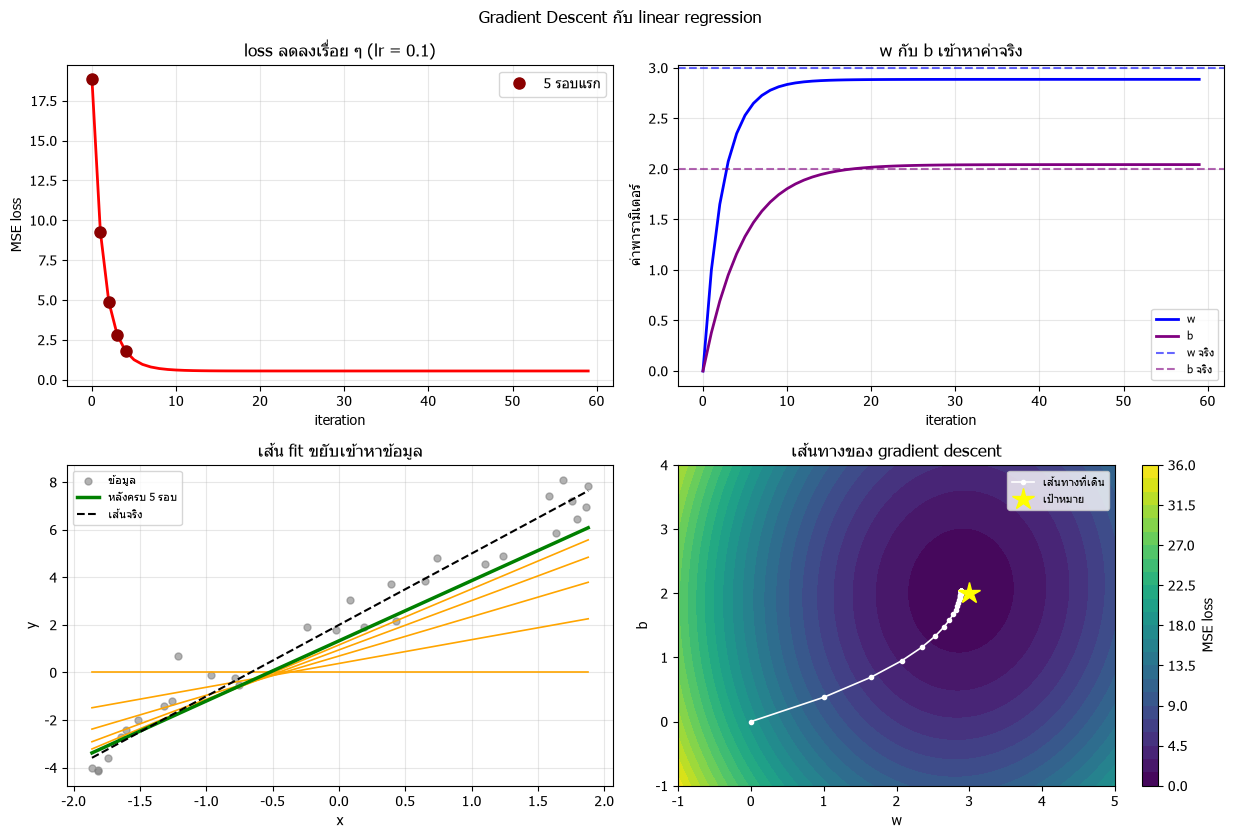

In [29]:
# โจทย์ให้แค่ 5 รอบ แต่ลองรันต่ออีกหน่อยเพื่อดูว่าสุดท้ายมันลู่เข้าไหม
w_t = 0.0
b_t = 0.0
iters = []
w_list = []
b_list = []
loss_list = []

for step in range(60):
    iters.append(step)
    w_list.append(w_t)
    b_list.append(b_t)
    loss_list.append(mse_loss(X_data, y_data, w_t, b_t))

    dw, db = gradients(X_data, y_data, w_t, b_t)
    w_t = w_t - lr * dw
    b_t = b_t - lr * db

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.5))

# รูปที่ 1 loss ลดลงทุกรอบ
axes[0, 0].plot(iters, loss_list, color="red", lw=2)
axes[0, 0].plot(hist_df["iteration"], hist_df["MSE_loss"], "o", color="darkred", ms=8, label="5 รอบแรก")
axes[0, 0].set_xlabel("iteration")
axes[0, 0].set_ylabel("MSE loss")
axes[0, 0].set_title("loss ลดลงเรื่อย ๆ (lr = " + str(lr) + ")")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# รูปที่ 2 w กับ b ค่อย ๆ เข้าหาค่าจริง
axes[0, 1].plot(iters, w_list, color="blue", lw=2, label="w")
axes[0, 1].plot(iters, b_list, color="purple", lw=2, label="b")
axes[0, 1].axhline(true_w, color="blue", ls="--", alpha=0.6, label="w จริง")
axes[0, 1].axhline(true_b, color="purple", ls="--", alpha=0.6, label="b จริง")
axes[0, 1].set_xlabel("iteration")
axes[0, 1].set_ylabel("ค่าพารามิเตอร์")
axes[0, 1].set_title("w กับ b เข้าหาค่าจริง")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(alpha=0.3)

# รูปที่ 3 เส้น fit ขยับเข้าหาข้อมูลทีละรอบ
xs_line = np.linspace(X_data.min(), X_data.max(), 50)
axes[1, 0].scatter(X_data, y_data, s=25, alpha=0.6, color="gray", label="ข้อมูล")
for i in range(len(hist_df)):
    axes[1, 0].plot(xs_line, hist_df["w"][i] * xs_line + hist_df["b"][i], color="orange", lw=1.2)
axes[1, 0].plot(xs_line, w_cur * xs_line + b_cur, color="green", lw=2.5, label="หลังครบ 5 รอบ")
axes[1, 0].plot(xs_line, true_w * xs_line + true_b, color="black", ls="--", lw=1.5, label="เส้นจริง")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("y")
axes[1, 0].set_title("เส้น fit ขยับเข้าหาข้อมูล")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.3)

# รูปที่ 4 เส้นทางเดินบน loss surface
wg, bg = np.meshgrid(np.linspace(-1, 5, 80), np.linspace(-1, 4, 80))
loss_grid = np.zeros(wg.shape)
for i in range(wg.shape[0]):
    for j in range(wg.shape[1]):
        loss_grid[i, j] = mse_loss(X_data, y_data, wg[i, j], bg[i, j])

cs = axes[1, 1].contourf(wg, bg, loss_grid, levels=25, cmap="viridis")
axes[1, 1].plot(w_list, b_list, "-o", color="white", ms=3, lw=1.2, label="เส้นทางที่เดิน")
axes[1, 1].plot(true_w, true_b, "*", color="yellow", ms=16, label="เป้าหมาย")
plt.colorbar(cs, ax=axes[1, 1], label="MSE loss")
axes[1, 1].set_xlabel("w")
axes[1, 1].set_ylabel("b")
axes[1, 1].set_title("เส้นทางของ gradient descent")
axes[1, 1].legend(fontsize=8)

plt.suptitle("Gradient Descent กับ linear regression")
plt.tight_layout()
plt.show()

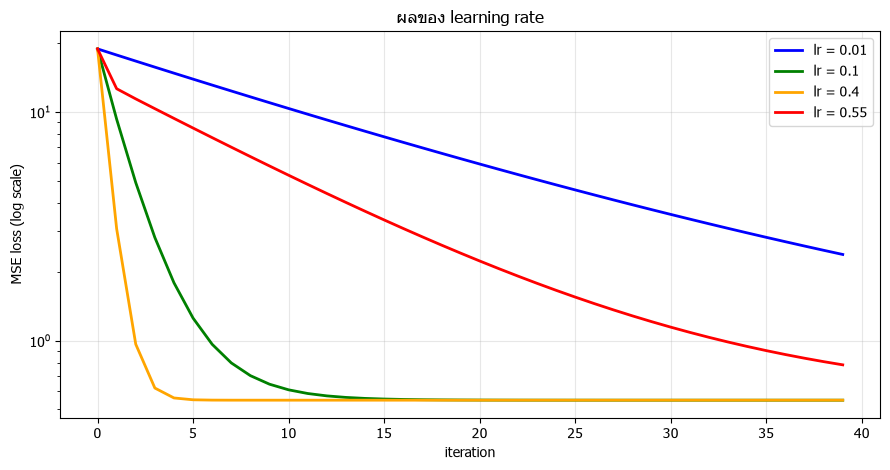

สรุป: lr เล็กไป -> ลู่เข้าช้า | lr พอดี -> เร็วและนิ่ง | lr ใหญ่ไป -> แกว่งหรือลู่ออก


In [30]:
# ลองเปลี่ยน learning rate ดูว่าผลต่างกันยังไง
lr_list = [0.01, 0.1, 0.4, 0.55]
color_list = ["blue", "green", "orange", "red"]

fig, ax = plt.subplots(figsize=(9, 4.8))

for k in range(len(lr_list)):
    ww = 0.0
    bb = 0.0
    losses = []
    for step in range(40):
        losses.append(mse_loss(X_data, y_data, ww, bb))
        dw, db = gradients(X_data, y_data, ww, bb)
        ww = ww - lr_list[k] * dw
        bb = bb - lr_list[k] * db
        if not np.isfinite(ww) or abs(ww) > 1e6:    # ลู่ออกแล้ว หยุดเลย
            break
    ax.plot(losses, color=color_list[k], lw=2, label="lr = " + str(lr_list[k]))

ax.set_yscale("log")
ax.set_xlabel("iteration")
ax.set_ylabel("MSE loss (log scale)")
ax.set_title("ผลของ learning rate")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("สรุป: lr เล็กไป -> ลู่เข้าช้า | lr พอดี -> เร็วและนิ่ง | lr ใหญ่ไป -> แกว่งหรือลู่ออก")

---
# Section 5 - Descriptive Statistics

สถิติเชิงพรรณนา ใช้ **สรุปลักษณะของข้อมูล** ให้เหลือตัวเลขไม่กี่ตัวที่เล่าเรื่องได้
เป็นด่านแรกของการทำ EDA (Exploratory Data Analysis) ก่อนสร้างโมเดล

**ข้อมูลที่ใช้:** สุ่มข้อมูลจำลอง 2 ชุด
- `height` — ส่วนสูง (นิยมแจกแจงแบบปกติ / normal distribution)
- `weight` — น้ำหนัก ซึ่งสัมพันธ์กับส่วนสูง (เพื่อใช้ดู covariance & correlation)

In [31]:
# สุ่มข้อมูลส่วนสูงกับน้ำหนักไว้ทำสถิติ
N = 200
height = np.random.normal(168, 8, N)                      # เฉลี่ย 168 cm, SD 8
weight = 0.75 * height - 62 + np.random.normal(0, 5, N)   # ให้สัมพันธ์กับส่วนสูง แล้วบวก noise

df = pd.DataFrame({"height_cm": height, "weight_kg": weight})

print("จำนวนข้อมูล =", N)
display(df.head())
print("สรุปด้วย describe()")
display(df.describe())

จำนวนข้อมูล = 200


,height_cm,weight_kg
0,164.8109,61.9007
1,167.5131,75.3748
2,156.6500,57.5124
3,176.3399,74.8036
4,175.2283,68.4089


สรุปด้วย describe()


,height_cm,weight_kg
count,200.0000,200.0000
mean,168.7529,65.1120
std,7.7389,7.9776
min,146.7586,45.2382
25%,163.6426,59.4849
50%,168.3734,65.7562
75%,174.8282,69.9710
max,189.8754,83.9476


## 5.1a – 5.8h ค่าสถิติพื้นฐาน

$$
\text{Mean:}\quad \bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i
\qquad\qquad
\text{Median:}\quad \tilde{x} = \text{ค่ากลางเมื่อเรียงข้อมูลแล้ว}
$$

$$
\text{Range} = \max(x) - \min(x)
\qquad\qquad
\text{IQR} = Q_3 - Q_1
$$

$$
\text{Variance:}\quad s^{2} = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^{2}
\qquad\qquad
\text{Standard Deviation:}\quad s = \sqrt{s^{2}}
$$

> **หมายเหตุ** ตัวหาร $n-1$ คือ *sample variance* (Bessel's correction) ซึ่งเป็นค่าที่ใช้กับข้อมูลตัวอย่าง
> ใน NumPy ต้องระบุ `ddof=1` ส่วน pandas ใช้ `ddof=1` เป็นค่าเริ่มต้นอยู่แล้ว
>
> **Mean vs Median:** mean ไวต่อค่าผิดปกติ (outlier) ส่วน median ทนทานกว่า

In [32]:
col = df["height_cm"].values

mean_v = np.mean(col)
median_v = np.median(col)
min_v = np.min(col)
max_v = np.max(col)
range_v = max_v - min_v
q1, q3 = np.percentile(col, [25, 75])
iqr_v = q3 - q1
var_v = np.var(col, ddof=1)     # ddof=1 เพราะเป็น sample ไม่ใช่ทั้ง population
std_v = np.std(col, ddof=1)

names = ["Mean", "Median", "Min", "Max", "Range", "Q1", "Q3", "IQR", "Variance", "Std"]
values = [mean_v, median_v, min_v, max_v, range_v, q1, q3, iqr_v, var_v, std_v]

stats_table = pd.DataFrame({"สถิติ": names, "ค่า": np.round(values, 4)})
print("สถิติเชิงพรรณนาของ height_cm")
display(stats_table)

# ลองคำนวณ variance เองตามนิยาม
total = 0
for v in col:
    total += (v - mean_v) ** 2
manual_var = total / (len(col) - 1)

print("variance คำนวณเอง    =", round(manual_var, 6), " | numpy =", round(var_v, 6))
print("std = sqrt(variance) =", round(np.sqrt(var_v), 6), " | numpy =", round(std_v, 6))

สถิติเชิงพรรณนาของ height_cm


,สถิติ,ค่า
0,Mean,168.7529
1,Median,168.3734
2,Min,146.7586
3,Max,189.8754
4,Range,43.1168
5,Q1,163.6426
6,Q3,174.8282
7,IQR,11.1856
8,Variance,59.8906
9,Std,7.7389


variance คำนวณเอง    = 59.890625  | numpy = 59.890625
std = sqrt(variance) = 7.738903  | numpy = 7.738903


## 5.9i Histogram

**Histogram** แสดง *การแจกแจงความถี่* ของข้อมูล — ช่วยดูรูปร่าง (shape), ความเบ้ (skewness) และค่ากลาง

ในกราฟจะทำเครื่องหมาย mean และ median ไว้เทียบกัน และแรเงาช่วง $\bar{x} \pm s$
ซึ่งครอบคลุมข้อมูลราว **68%** เมื่อข้อมูลมีการแจกแจงแบบปกติ

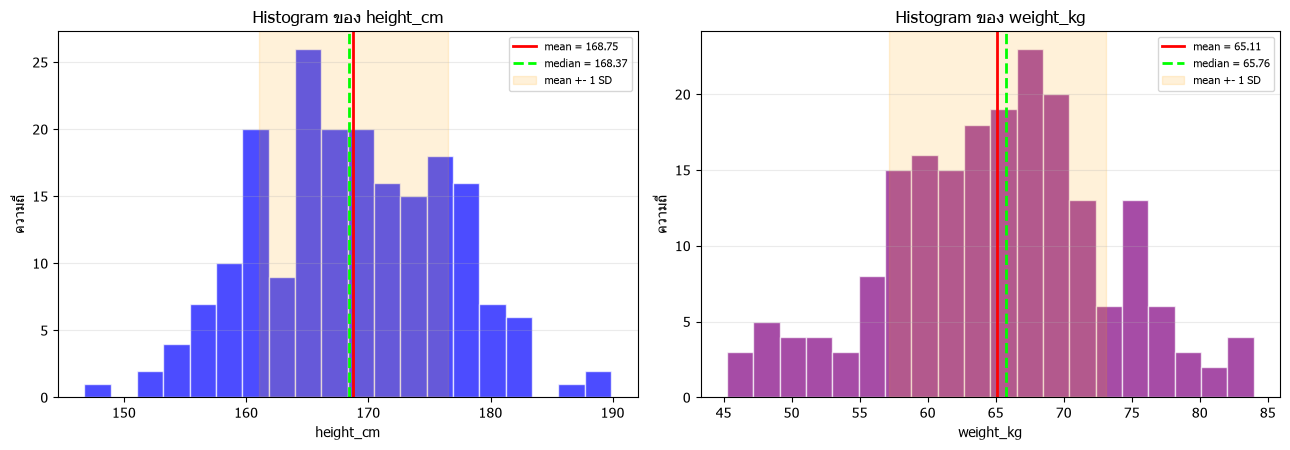

In [33]:
cols = ["height_cm", "weight_kg"]
colors = ["blue", "purple"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

for i in range(2):
    data = df[cols[i]].values
    m = np.mean(data)
    md = np.median(data)
    s = np.std(data, ddof=1)

    axes[i].hist(data, bins=20, color=colors[i], alpha=0.7, edgecolor="white")
    axes[i].axvline(m, color="red", lw=2, label="mean = " + str(round(m, 2)))
    axes[i].axvline(md, color="lime", lw=2, ls="--", label="median = " + str(round(md, 2)))
    axes[i].axvspan(m - s, m + s, color="orange", alpha=0.15, label="mean +- 1 SD")
    axes[i].set_xlabel(cols[i])
    axes[i].set_ylabel("ความถี่")
    axes[i].set_title("Histogram ของ " + cols[i])
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.25, axis="y")

plt.tight_layout()
plt.show()

## 5.10j Box Plot

**Box Plot** สรุปข้อมูลด้วย *five-number summary*: $\min$, $Q_1$, median, $Q_3$, $\max$

- **กล่อง (box)** = ช่วง $Q_1$ ถึง $Q_3$ (คือ IQR — ครอบคลุมข้อมูลตรงกลาง 50%)
- **เส้นในกล่อง** = median
- **หนวด (whiskers)** = ขยายไปไม่เกิน $1.5 \times IQR$ จากขอบกล่อง
- **จุดนอกหนวด** = จุดที่ *น่าสงสัยว่าเป็น outlier*

$$
\text{ขอบเขต outlier}: \quad [\,Q_1 - 1.5\,IQR,\;\; Q_3 + 1.5\,IQR\,]
$$

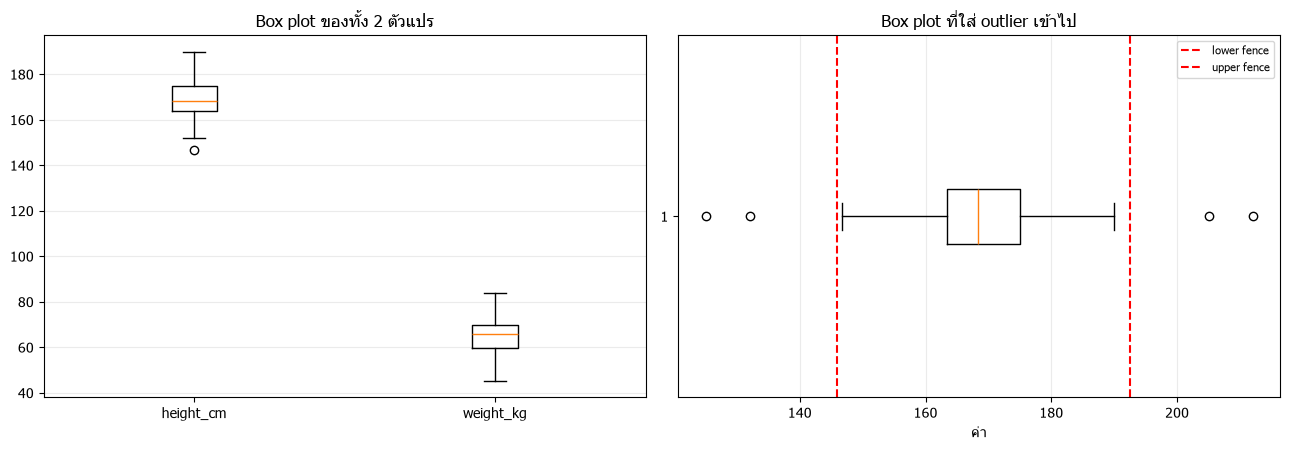

Q1 = 163.3439 , Q3 = 174.9764 , IQR = 11.6324
ช่วงที่ถือว่าปกติ = 145.8953 ถึง 192.425
ค่าที่เป็น outlier มี 4 ค่า : [125. 132. 205. 212.]


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# รูปซ้าย box plot ของทั้ง 2 ตัวแปร
axes[0].boxplot([df["height_cm"], df["weight_kg"]],
                tick_labels=["height_cm", "weight_kg"])
axes[0].set_title("Box plot ของทั้ง 2 ตัวแปร")
axes[0].grid(alpha=0.25, axis="y")

# รูปขวา ลองใส่ outlier เข้าไป ดูว่า IQR fence จับได้ไหม
data_out = np.append(df["height_cm"].values, [125, 132, 205, 212])
q1o, q3o = np.percentile(data_out, [25, 75])
iqro = q3o - q1o
low_f = q1o - 1.5 * iqro
up_f = q3o + 1.5 * iqro

outliers = []
for v in data_out:
    if v < low_f or v > up_f:
        outliers.append(v)

axes[1].boxplot(data_out, orientation="horizontal")
axes[1].axvline(low_f, color="red", ls="--", lw=1.5, label="lower fence")
axes[1].axvline(up_f, color="red", ls="--", lw=1.5, label="upper fence")
axes[1].set_title("Box plot ที่ใส่ outlier เข้าไป")
axes[1].set_xlabel("ค่า")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25, axis="x")

plt.tight_layout()
plt.show()

print("Q1 =", round(q1o, 4), ", Q3 =", round(q3o, 4), ", IQR =", round(iqro, 4))
print("ช่วงที่ถือว่าปกติ =", round(low_f, 4), "ถึง", round(up_f, 4))
print("ค่าที่เป็น outlier มี", len(outliers), "ค่า :", np.sort(outliers))

## 5.11k Covariance and Correlation

### Covariance — บอก *ทิศทาง* ของการเปลี่ยนแปลงร่วมกัน

$$
\mathrm{Cov}(X,Y) = \frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
$$

ปัญหาคือค่านี้ **ขึ้นกับหน่วยของข้อมูล** จึงเทียบข้ามคู่ตัวแปรไม่ได้

### Correlation (Pearson) — ทำให้เป็นมาตรฐาน ไร้หน่วย

$$
r_{XY} = \frac{\mathrm{Cov}(X,Y)}{s_X \, s_Y}
\qquad r \in [-1, 1]
$$

| $r$ | ความหมาย |
|-----|----------|
| ใกล้ $+1$ | ตัวแปรเพิ่มไปด้วยกัน (สัมพันธ์เชิงบวก) |
| ใกล้ $0$ | ไม่มีความสัมพันธ์ **เชิงเส้น** |
| ใกล้ $-1$ | ตัวหนึ่งเพิ่ม อีกตัวลด |

> ⚠️ **ข้อควรระวัง 2 ข้อ**
> 1. **Correlation ไม่ได้แปลว่าเป็นเหตุเป็นผล (correlation ≠ causation)**
> 2. Pearson จับได้เฉพาะความสัมพันธ์ **เชิงเส้น** — ข้อมูลรูปโค้ง (เช่นพาราโบลา) อาจได้ $r \approx 0$ ทั้งที่สัมพันธ์กันชัดเจน จึงควร **พล็อตดูเสมอ**

In [35]:
h = df["height_cm"].values
wt = df["weight_kg"].values

# คำนวณเองตามนิยาม
cov_manual = np.sum((h - h.mean()) * (wt - wt.mean())) / (len(h) - 1)
corr_manual = cov_manual / (np.std(h, ddof=1) * np.std(wt, ddof=1))

# ใช้ฟังก์ชันของ numpy
cov_matrix = np.cov(h, wt)
corr_matrix = np.corrcoef(h, wt)

print("Covariance matrix (แนวทแยงคือ variance ของแต่ละตัวแปร)")
display(pd.DataFrame(cov_matrix, index=["height", "weight"], columns=["height", "weight"]))

print("Correlation matrix")
display(pd.DataFrame(corr_matrix, index=["height", "weight"], columns=["height", "weight"]))

print("covariance คำนวณเอง  =", round(cov_manual, 6), " | numpy =", round(cov_matrix[0, 1], 6))
print("correlation คำนวณเอง =", round(corr_manual, 6), " | numpy =", round(corr_matrix[0, 1], 6))
print()
print("r =", round(corr_matrix[0, 1], 4), "-> สัมพันธ์กันเชิงบวกชัดเจน คนสูงมักจะหนักกว่า")

Covariance matrix (แนวทแยงคือ variance ของแต่ละตัวแปร)


,height,weight
height,59.8906,48.3093
weight,48.3093,63.6422


Correlation matrix


,height,weight
height,1.0000,0.7825
weight,0.7825,1.0000


covariance คำนวณเอง  = 48.309299  | numpy = 48.309299
correlation คำนวณเอง = 0.78249  | numpy = 0.78249

r = 0.7825 -> สัมพันธ์กันเชิงบวกชัดเจน คนสูงมักจะหนักกว่า


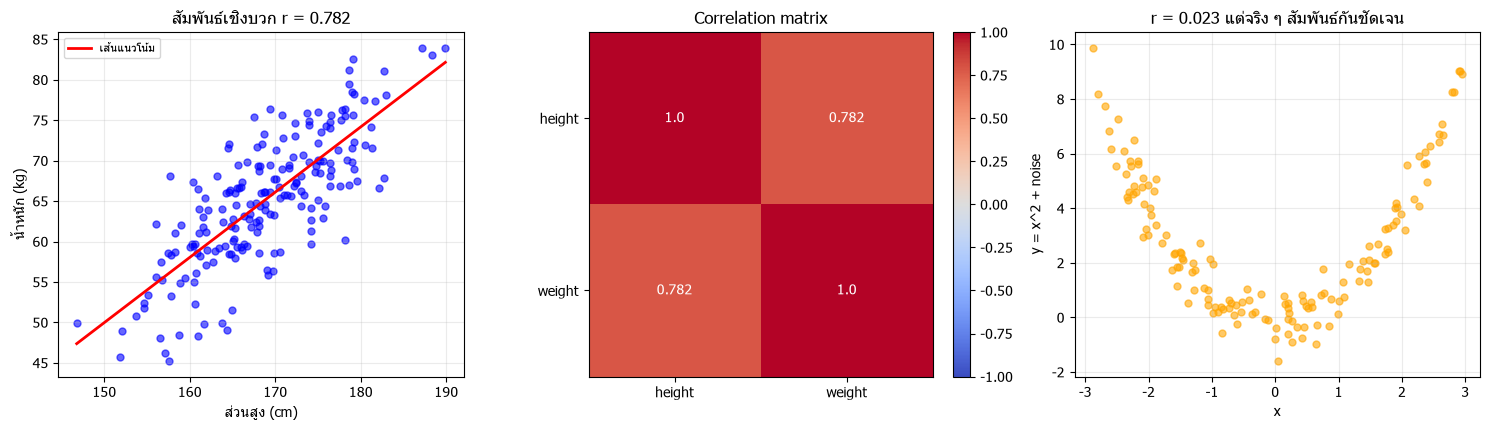

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

# รูปที่ 1 scatter กับเส้นแนวโน้ม
slope, intercept = np.polyfit(h, wt, 1)
xs_fit = np.linspace(h.min(), h.max(), 50)
axes[0].scatter(h, wt, s=25, alpha=0.6, color="blue")
axes[0].plot(xs_fit, slope * xs_fit + intercept, color="red", lw=2, label="เส้นแนวโน้ม")
axes[0].set_xlabel("ส่วนสูง (cm)")
axes[0].set_ylabel("น้ำหนัก (kg)")
axes[0].set_title("สัมพันธ์เชิงบวก r = " + str(round(corr_matrix[0, 1], 3)))
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

# รูปที่ 2 heatmap ของ correlation matrix
im = axes[1].imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set_xticks([0, 1], ["height", "weight"])
axes[1].set_yticks([0, 1], ["height", "weight"])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, round(corr_matrix[i, j], 3), ha="center", va="center", color="white")
axes[1].set_title("Correlation matrix")
plt.colorbar(im, ax=axes[1], fraction=0.046)

# รูปที่ 3 กับดัก ถ้าความสัมพันธ์ไม่เป็นเส้นตรง r จะใกล้ 0 ทั้งที่จริง ๆ สัมพันธ์กัน
x_non = np.random.uniform(-3, 3, 150)
y_non = x_non ** 2 + np.random.normal(0, 0.6, 150)
r_non = np.corrcoef(x_non, y_non)[0, 1]
axes[2].scatter(x_non, y_non, s=25, alpha=0.6, color="orange")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y = x^2 + noise")
axes[2].set_title("r = " + str(round(r_non, 3)) + " แต่จริง ๆ สัมพันธ์กันชัดเจน")
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()